# Load cells info


In [1]:
import numpy as np
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from bluepysnap import Circuit
from bluepysnap.bbp import Cell

CircuitPath = 'O1_data_physiology/' # edges files not inclued in https://github.com/FernandoSBorges/
circuit_path = CircuitPath + 'circuit_config.json'
circuit = Circuit(circuit_path)
cells = circuit.nodes["S1nonbarrel_neurons"]
nodesinfo = cells.get()

%matplotlib inline

In [2]:
nodesinfo[nodesinfo['layer'] == '4'].head()

,etype,exc_mini_frequency,hexagon,inh_mini_frequency,layer,me_combo,model_template,model_type,morph_class,morphology,...,x,x_new,y,y_new,z,z_new,@dynamics:holding_current,@dynamics:input_resistance,@dynamics:resting_potential,@dynamics:threshold_current
node_ids,,,,,,,,,,,,,,,,,,,,,
108727,dSTUT,0.010108,2,0.233243,4,dSTUT_L4BP_L4_BP_4_C300797C-I1_-_Scale_x1.000_...,hoc:dSTUT_L4BP,biophysical,INT,C300797C-I1_-_Scale_x1.000_y0.975_z1.000_-_Clo...,...,3918.383222,345.100991,-882.079924,368.523207,-1946.094942,1431.980963,-0.048744,103.355850,-77.048584,0.092756
108728,bAC,0.010108,1,0.233243,4,bAC_L23BTC_L4_BP_4_rp140319_ChC_3_idA_-_Scale_...,hoc:bAC_L23BTC,biophysical,INT,rp140319_ChC_3_idA_-_Scale_x1.000_y0.975_z1.00...,...,4140.810336,179.239589,-766.305463,605.707003,-2090.662966,1435.342921,-0.011682,606.258118,-76.392754,0.024155
108729,cNAC,0.010108,0,0.233243,4,cNAC_L6NGC_L4_BP_4_C300797C-I1_-_Scale_x1.000_...,hoc:cNAC_L6NGC,biophysical,INT,C300797C-I1_-_Scale_x1.000_y0.950_z1.000_-_Clo...,...,3953.899058,722.166787,-1279.341226,593.262166,-2143.970161,1357.507449,-0.025396,385.013672,-74.105980,0.033770
108730,cACint,0.010108,0,0.233243,4,cACint_L4CHC_L4_BP_4_rp140319_ChC_3_idA_-_Scal...,hoc:cACint_L4CHC,biophysical,INT,rp140319_ChC_3_idA_-_Scale_x1.000_y0.975_z1.00...,...,4214.386218,740.411420,-1362.666051,842.778874,-2201.251811,1481.951494,-0.014442,636.180054,-73.075333,0.015156
108731,cACint,0.010108,0,0.233243,4,cACint_L4CHC_L4_BP_4_rp140319_ChC_3_idA_-_Scal...,hoc:cACint_L4CHC,biophysical,INT,rp140319_ChC_3_idA_-_Scale_x1.000_y1.025_z1.00...,...,4184.420803,714.604811,-1328.656268,916.399225,-2366.952165,1328.898361,-0.014949,620.984924,-72.957344,0.015535


In [3]:
nodesinfo.keys()

Index(['etype', 'exc_mini_frequency', 'hexagon', 'inh_mini_frequency', 'layer',
       'me_combo', 'model_template', 'model_type', 'morph_class', 'morphology',
       'mtype', 'orientation_w', 'orientation_x', 'orientation_y',
       'orientation_z', 'region', 'synapse_class', 'x', 'x_new', 'y', 'y_new',
       'z', 'z_new', '@dynamics:holding_current', '@dynamics:input_resistance',
       '@dynamics:resting_potential', '@dynamics:threshold_current'],
      dtype='object')

In [4]:
def distance3D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2)+np.power(nodesinfo['z'][gidpre]-nodesinfo['z'][gidpost],2))

def distance2D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2))

def distance2Dmean(gidpre, mean_x, mean_y):
    return np.sqrt(np.power(nodesinfo['x_new'][gidpre]-mean_x,2)+np.power(nodesinfo['y_new'][gidpre]-mean_y,2))

print(cells.property_values(Cell.REGION))

mtypes = sorted(cells.property_values(Cell.MTYPE))

i = 0
mntypes = {}
for mn in sorted(mtypes):
    mntypes[mn] = i
    i+=1

{'S1DZ', 'S1J', 'S1FL'}


In [5]:
f = open('node_sets.json')
node_sets = json.load(f)

mean_x, mean_y = np.mean(nodesinfo['x_new']), np.mean(nodesinfo['y_new'])
node_gid = []
nodepremtype_new = []
mtype_new = []


node_gid = []
hoclist = []
Morpholist = []
node_threshold_current = []
node_holding_current = []


hex = 'hex0'
for gid in node_sets['hex0']['node_id']:
# for gid in [117619, 142340, 142768, 142891, 141786,138337, 142077, 138315, 141829, 142671, 142352, 138475, 141536, 142859, 142058, 142814]:
# for gid in [141766, 138220, 108767, 108729, 108749, 138433, 141757, 141803, 138337]:

# for gid in [141369, 129252, 133426, 114284]:
    if 'L4_SSC' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 0.0 and distance2Dmean(gid, mean_x, mean_y) < 50.0 and 'EXC' in nodesinfo['synapse_class'][gid]:
        nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
        if nodesinfo['mtype'][gid] not in mtype_new:
            mtype_new.append(nodesinfo['mtype'][gid])

        iV70 = (-73.0 - nodesinfo['@dynamics:resting_potential'][gid])/nodesinfo['@dynamics:input_resistance'][gid]

        # print(len(node_gid),gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid],nodesinfo['model_template'][gid],nodesinfo['morphology'][gid],hex,distance2Dmean(gid, mean_x, mean_y))
        print("%d \t%d %s %s %.1f %.2f %.1f %.2f" % (len(node_gid),gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid], 
                                                     1000*(nodesinfo['@dynamics:threshold_current'][gid]+nodesinfo['@dynamics:holding_current'][gid]-iV70),nodesinfo['@dynamics:resting_potential'][gid],
                                                     1000*iV70,nodesinfo['@dynamics:input_resistance'][gid]))

        current1 = cells.get(gid,['@dynamics:threshold_current']).values[0]
        holding_current1 = cells.get(gid,['@dynamics:holding_current']).values[0]
        # print("%d %.5f %.5f" % (gid,current1,holding_current1))

        node_gid.append(gid)
        hoclist.append(nodesinfo['model_template'][gid][4:])
        Morpholist.append(nodesinfo['morphology'][gid])
        node_threshold_current.append(current1)
        node_holding_current.append(holding_current1)



# non central col
# for hex in node_sets['hex_O1']:
#     for gid in node_sets[hex]['node_id']:
#         if 'L4' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 500.0 and distance2Dmean(gid, mean_x, mean_y) < 502.0:
#             node_gid.append(gid)
#             nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
#             if nodesinfo['mtype'][gid] not in mtype_new:
#                 mtype_new.append(nodesinfo['mtype'][gid])

#             print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))

0 	138792 EXC L4_SSC 27.6 -75.74 22.6 120.92
1 	138906 EXC L4_SSC 23.0 -78.45 43.0 126.70
2 	138912 EXC L4_SSC 28.2 -75.73 15.8 173.25
3 	138968 EXC L4_SSC 32.7 -75.47 20.0 123.79
4 	138978 EXC L4_SSC 29.0 -75.84 23.3 121.83
5 	139754 EXC L4_SSC 14.7 -78.73 34.3 166.88
6 	139757 EXC L4_SSC 30.0 -75.75 21.5 127.91
7 	139790 EXC L4_SSC 23.1 -76.14 18.8 166.87
8 	139867 EXC L4_SSC 11.5 -76.92 19.7 198.67
9 	139916 EXC L4_SSC 14.2 -79.14 35.4 173.61
10 	140018 EXC L4_SSC 25.1 -78.61 42.7 131.48
11 	140058 EXC L4_SSC 30.0 -75.64 21.9 120.23
12 	140346 EXC L4_SSC 20.5 -76.07 18.7 163.91
13 	140408 EXC L4_SSC 6.8 -79.32 27.5 230.18
14 	140412 EXC L4_SSC 32.7 -75.81 24.7 113.69
15 	140656 EXC L4_SSC 11.4 -76.76 13.2 285.03
16 	140868 EXC L4_SSC 21.6 -76.65 24.7 147.83
17 	140931 EXC L4_SSC 19.6 -76.24 21.9 148.18
18 	141017 EXC L4_SSC 21.3 -78.60 40.0 139.96
19 	141159 EXC L4_SSC 25.3 -76.43 23.2 148.02
20 	141213 EXC L4_SSC 19.1 -78.55 39.2 141.59
21 	141369 EXC L4_SSC 9.5 -79.19 26.6 232.35


# Testing over all reconstruct cells

In [6]:
from netpyne import specs, sim

# Network parameters
netParams = specs.NetParams()  # object of class NetParams to store the network parameters

In [7]:
cellName_list = {}
cellName_list2 = []
gid_list = {}

Epops = []
Ipops = []

cellName_list2 = []

# node_gid = [139867, 141213, 141369, 133426, 135956, 137858, 114264, 114284, 115007]

node_gid

for gid in node_gid:
# for gid in [108767, 141766, 138433, 139867, 141213, 141369, 133426, 135956, 137858, 114264, 114284, 115007]:
# for gid in [108767, 141766, 138433, 141213, 133426, 135956,  137858, 114264]:
# for gid in [114264]:

    cellName = nodesinfo['mtype'][gid] + '_' + nodesinfo['etype'][gid]

    cellName_list2.append(cellName)

    cellName_list[gid] = cellName + '_' + str(len(cellName_list2)-1)
    gid_list[cellName + '_' + str(len(cellName_list2)-1)] = gid

    print('%s %s %s 1 1 %d' % (cellName + '_' + str(len(cellName_list2)-1),nodesinfo['mtype'][gid],nodesinfo['etype'][gid],gid))

    if 'cADpyr' in cellName:
        Epops.append(cellName + '_' + str(len(cellName_list2)-1))
    else:
        Ipops.append(cellName + '_' + str(len(cellName_list2)-1))

        

L4_SSC_cADpyr_0 L4_SSC cADpyr 1 1 138792
L4_SSC_cADpyr_1 L4_SSC cADpyr 1 1 138906
L4_SSC_cADpyr_2 L4_SSC cADpyr 1 1 138912
L4_SSC_cADpyr_3 L4_SSC cADpyr 1 1 138968
L4_SSC_cADpyr_4 L4_SSC cADpyr 1 1 138978
L4_SSC_cADpyr_5 L4_SSC cADpyr 1 1 139754
L4_SSC_cADpyr_6 L4_SSC cADpyr 1 1 139757
L4_SSC_cADpyr_7 L4_SSC cADpyr 1 1 139790
L4_SSC_cADpyr_8 L4_SSC cADpyr 1 1 139867
L4_SSC_cADpyr_9 L4_SSC cADpyr 1 1 139916
L4_SSC_cADpyr_10 L4_SSC cADpyr 1 1 140018
L4_SSC_cADpyr_11 L4_SSC cADpyr 1 1 140058
L4_SSC_cADpyr_12 L4_SSC cADpyr 1 1 140346
L4_SSC_cADpyr_13 L4_SSC cADpyr 1 1 140408
L4_SSC_cADpyr_14 L4_SSC cADpyr 1 1 140412
L4_SSC_cADpyr_15 L4_SSC cADpyr 1 1 140656
L4_SSC_cADpyr_16 L4_SSC cADpyr 1 1 140868
L4_SSC_cADpyr_17 L4_SSC cADpyr 1 1 140931
L4_SSC_cADpyr_18 L4_SSC cADpyr 1 1 141017
L4_SSC_cADpyr_19 L4_SSC cADpyr 1 1 141159
L4_SSC_cADpyr_20 L4_SSC cADpyr 1 1 141213
L4_SSC_cADpyr_21 L4_SSC cADpyr 1 1 141369
L4_SSC_cADpyr_22 L4_SSC cADpyr 1 1 141522


In [8]:
cellsList = {}

for cellName in gid_list.keys():
    # try:
        gid = gid_list[cellName]

        MorphoName = nodesinfo['morphology'][gid] + '.asc'

        hocName = nodesinfo['model_template'][gid][4:]

        MorphologyPath = 'O1_data_physiology/morphologies/ascii'

        # MorphoName = nodesinfo['morphology'][gid]+"_gid"+str(gid)+".asc"

        print(cellName,hocName)

        cellRule = netParams.importCellParams(label=cellName, somaAtOrigin=True,
            conds={'cellType': cellName, 'cellModel': 'HH_full'},
            fileName='O1_data_physiology/emodels_hoc/' + hocName + '.hoc',
            cellName=hocName,
            cellInstance = False,
            cellArgs=[gid, MorphologyPath, MorphoName])

        # netParams.saveCellParamsRule(label=cellName, fileName=cellName+'_BBP_cellParams.json')


        # netParams.cellParams[cellName]['secs']['axon_0']['geom']['Ra'] = 2.0*netParams.cellParams[cellName]['secs']['axon_0']['geom']['Ra']

        cellsList[cellName] = [{'x': nodesinfo['x'][gid], 'y': nodesinfo['y'][gid], 'z': nodesinfo['z'][gid]}]
        # cellsList[cellName] = [{'x': nodesinfo['x'][gid] - 3000.0, 'y': nodesinfo['y'][gid] + 2000.0, 'z': nodesinfo['z'][gid] + 3500.0}]

        cellMe = cellName

        axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, soma_pt3d_diam =  netParams.cellParams[cellMe]['secs']['soma_0']['geom']['pt3d'][-1]

        netParams.cellParams[cellMe]['secs']['axon_0']['geom']['diam'] = 3.0
        # netParams.cellParams[cellMe]['secs']['axon_0']['geom']['L'] = 30.0

        axon_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['diam']
        axon_pt3d_L =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['L']

        netParams.cellParams[cellMe]['secs']['axon_0']['geom']['pt3d'] = [(axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L/2.0, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L, axon_pt3d_z, axon_pt3d_diam)]



        axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon_0_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['pt3d'][-1]

        # netParams.cellParams[cellMe]['secs']['axon_1']['geom']['diam'] = 0.5
        # netParams.cellParams[cellMe]['secs']['axon_1']['geom']['L'] = 30.0

        axon1_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['diam']
        axon1_pt3d_L =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['L']

        netParams.cellParams[cellMe]['secs']['axon_1']['geom']['pt3d'] = [(axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L/2.0, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L, axon1_pt3d_z, axon1_pt3d_diam)]



        myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, axon_1_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['pt3d'][-1]

        # netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['diam'] = 0.5
        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['L'] = 100.0

        myelin_pt3d_diam =  netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['diam']
        myelin_pt3d_L =  netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['L']

        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['pt3d'] = [(myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L/2.0, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L, myelin_pt3d_z, myelin_pt3d_diam)]

    # except:
    #     pass

# cellsList

L4_SSC_cADpyr_0 cADpyr_L4UPC
L4_SSC_cADpyr_1 cADpyr_L4TPC
L4_SSC_cADpyr_2 cADpyr_L4UPC
L4_SSC_cADpyr_3 cADpyr_L4UPC
L4_SSC_cADpyr_4 cADpyr_L4UPC
L4_SSC_cADpyr_5 cADpyr_L4TPC
L4_SSC_cADpyr_6 cADpyr_L4UPC
L4_SSC_cADpyr_7 cADpyr_L4UPC
L4_SSC_cADpyr_8 cADpyr_L4UPC
L4_SSC_cADpyr_9 cADpyr_L4TPC
L4_SSC_cADpyr_10 cADpyr_L4TPC
L4_SSC_cADpyr_11 cADpyr_L4UPC
L4_SSC_cADpyr_12 cADpyr_L4UPC
L4_SSC_cADpyr_13 cADpyr_L4TPC
L4_SSC_cADpyr_14 cADpyr_L4UPC
L4_SSC_cADpyr_15 cADpyr_L4UPC
L4_SSC_cADpyr_16 cADpyr_L4UPC
L4_SSC_cADpyr_17 cADpyr_L4UPC
L4_SSC_cADpyr_18 cADpyr_L4TPC
L4_SSC_cADpyr_19 cADpyr_L4UPC
L4_SSC_cADpyr_20 cADpyr_L4TPC
L4_SSC_cADpyr_21 cADpyr_L4TPC
L4_SSC_cADpyr_22 cADpyr_L4UPC


In [9]:
list(netParams.cellParams[cellMe]['secs']['soma_0']['mechs'])

['CaDynamics_DC0',
 'Ca_HVA2',
 'Ca_LVAst',
 'Ih',
 'K_Pst',
 'K_Tst',
 'NaTg',
 'SK_E2',
 'SKv3_1',
 'pas']

In [10]:
# https://github.com/suny-downstate-medical-center/S1_mouse
# Layer	     height	  from	  to
# L1         0.089      0.000	0.089
# L2         0.070      0.089	0.159
# L3         0.128      0.159	0.286
# L4         0.134      0.286	0.421
# L5         0.263      0.421	0.684
# L6         0.316      0.684	1.000
# L23        0.198      0.089	0.286
# All     1378.8 um

layer = {'1':[0.0, 0.089], '2': [0.089,0.159], '3': [0.159,0.286], '23': [0.089,0.286], '4':[0.286,0.421], '5': [0.421,0.684], '6': [0.684,1.0],
'longS1': [2.2,2.3], 'longS2': [2.3,2.4]}  # normalized layer boundaries

#Th pop
ymin={'ss_RTN_o': 1688, 'ss_RTN_m': 1766, 'ss_RTN_i': 1844, 'VPL_sTC': 2000, 'VPM_sTC': 2156, 'POm_sTC_s1': 2312}
ymax={'ss_RTN_o': 1766, 'ss_RTN_m': 1844, 'ss_RTN_i': 2000, 'VPL_sTC': 2156, 'VPM_sTC': 2312, 'POm_sTC_s1': 2624}

#------------------------------------------------------------------------------
# General network parameters
#------------------------------------------------------------------------------
netParams.scale = 1.0 # Scale factor for number of cells
netParams.sizeX = 50.0 # x-dimension (horizontal length) size in um
netParams.sizeY = 1378.8 # y-dimension (vertical height or cortical depth) size in um
netParams.sizeZ = 50.0 # z-dimension (horizontal depth) size in um
netParams.shape = 'cylinder' # cylindrical (column-like) volume
netParams.rotateCellsRandomly = True

netParams.defaultThreshold = -20.0 # spike threshold, 10 mV is NetCon default, lower it for all cells
netParams.defaultDelay = 0.1 # default conn delay (ms)
netParams.propVelocity = 300.0 #  300 μm/ms (Stuart et al., 1997)
netParams.scaleConnWeightNetStims = 0.001  # weight conversion factor (from nS to uS)

#------------------------------------------------------------------------------
# load data from S1 Raster
#------------------------------------------------------------------------------
for metype in netParams.cellParams.keys():
    layernumber = metype[1:2]
    if layernumber == '2':
        netParams.popParams[metype] = {'cellType': metype, 'cellModel': 'HH_full', 'ynormRange': layer['23'],
                                            'numCells':1, 'diversity': True}
    else:
        netParams.popParams[metype] = {'cellType': metype, 'cellModel': 'HH_full', 'ynormRange': layer[layernumber],
                                            'numCells': 1, 'diversity': True}

In [11]:
netParams.popParams.keys()

odict_keys(['L4_SSC_cADpyr_0', 'L4_SSC_cADpyr_1', 'L4_SSC_cADpyr_2', 'L4_SSC_cADpyr_3', 'L4_SSC_cADpyr_4', 'L4_SSC_cADpyr_5', 'L4_SSC_cADpyr_6', 'L4_SSC_cADpyr_7', 'L4_SSC_cADpyr_8', 'L4_SSC_cADpyr_9', 'L4_SSC_cADpyr_10', 'L4_SSC_cADpyr_11', 'L4_SSC_cADpyr_12', 'L4_SSC_cADpyr_13', 'L4_SSC_cADpyr_14', 'L4_SSC_cADpyr_15', 'L4_SSC_cADpyr_16', 'L4_SSC_cADpyr_17', 'L4_SSC_cADpyr_18', 'L4_SSC_cADpyr_19', 'L4_SSC_cADpyr_20', 'L4_SSC_cADpyr_21', 'L4_SSC_cADpyr_22'])

In [12]:
#------------------------------------------------------------------------------
#
# SIMULATION CONFIGURATION
#
#------------------------------------------------------------------------------

cfg = specs.SimConfig()					            # object of class SimConfig to store simulation configuration

cfg.coreneuron = False

#------------------------------------------------------------------------------
# Run parameters
#------------------------------------------------------------------------------
cfg.duration = 7.0*1e3 ## Duration of the sim, in ms
cfg.dt = 0.05
cfg.seeds = {'cell': 4321, 'conn': 4321, 'stim': 1000, 'loc': 4321}
cfg.hParams = {'celsius': 34, 'v_init': -84.0}
cfg.verbose = False
cfg.createNEURONObj = True
cfg.createPyStruct = True
cfg.cvode_active = False
cfg.cvode_atol = 1e-6
cfg.cache_efficient = True
cfg.printRunTime = 0.1

cfg.includeParamsLabel = False
cfg.printPopAvgRates = True
cfg.checkErrors = False

#--------------------------------------------------------------------------
# Recording
#--------------------------------------------------------------------------
cfg.recordCells = list(netParams.popParams.keys())
# cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'}}  ## Dict with traces to record
cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_0': {'sec':'axon_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_1': {'sec':'axon_1', 'loc':0.5, 'var':'v'},
                    # 'V_myelin_0': {'sec':'myelin_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_15': {'sec':'axon_15', 'loc':0.5, 'var':'v'},
                    # 'V_apic_0': {'sec':'apic_0', 'loc':0.5, 'var':'v'},
                    # 'V_apic_7': {'sec':'apic_7', 'loc':0.5, 'var':'v'},
                    # 'V_apic_64': {'sec':'apic_64', 'loc':0.5, 'var':'v'},
                    # 'V_apic_86': {'sec':'apic_86', 'loc':0.5, 'var':'v'},
                    # 'V_dend_0': {'sec':'dend_0', 'loc':0.5, 'var':'v'},
                    # 'V_dend_5': {'sec':'dend_5', 'loc':0.5, 'var':'v'},
                    }
cfg.recordStim = False
cfg.recordTime = False
cfg.recordStep = 0.05

#------------------------------------------------------------------------------
# Saving
#------------------------------------------------------------------------------
cfg.simLabel = 'v0_batch0'       #   + str(cfg.cynradNumber)
cfg.saveFolder = 'exploration/data/'+cfg.simLabel
# cfg.filename =                	## Set file output name
cfg.savePickle = False	        	## Save pkl file
cfg.saveJson = False           	## Save json file
cfg.saveDataInclude = ['simData', 'simConfig', 'net', 'netParams'] ## ['simData'] ##  ['simData'] ##, , 'simConfig', 'netParams'
cfg.backupCfgFile = None 		##
cfg.gatherOnlySimData = False	##
cfg.saveCellSecs = True
cfg.saveCellConns = True

#------------------------------------------------------------------------------
# Analysis and plotting
# ------------------------------------------------------------------------------
cfg.analysis['plotRaster'] = {'include': cfg.recordCells, 'saveFig': True, 'showFig': False,'orderInverse': True, 'timeRange': [0,cfg.duration], 'figSize': (12,4), 'fontSize':4, 'markerSize':4, 'marker': 'o', 'dpi': 300}
# cfg.analysis['plot2Dnet']   = {'include': ['presyn_L23_PC_cAD','presyn_L5_TTPC2_cAD', 'presyn_VPM_sTC','L23_PC_cAD','L5_TTPC2_cAD'],'saveFig': True, 'showConns': False, 'figSize': (24,24), 'view': 'xz', 'fontSize':16}   # Plot 2D cells xy
# cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'ylim': [-100,50], 'saveFig': True, 'showFig': False, 'figSize':(24,24)}

cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'saveFig': False, 'showFig': True, 'figSize':(24,4)} # , 'ylim': [-90,30] Plot recorded traces for this list of cells
# cfg.analysis['plotShape'] = {'includePre':  [ii for ii in range(10)],'includePre':  [ii for ii in range(10)], 'saveFig': True, 'showFig': True, 'figSize':(12,12)}


In [13]:
for gid in node_gid: # list_pre:

    popName1 = cellName_list[gid]
    current1 = 1.0*cells.get(gid,['@dynamics:threshold_current']).values[0]
    holding_current1 = cells.get(gid,['@dynamics:holding_current']).values[0]

    # current1 = 0.3
    # holding_current1 = 0.0

    # netParams.stimSourceParams['Input_'+str(gid)] = {'type': 'IClamp', 'del': 0.0, 'dur': 2000.0, 'amp': holding_current1}
    # netParams.stimSourceParams['Inputb_'+str(gid)] = {'type': 'IClamp', 'del': 550.0, 'dur': 600.0, 'amp':current1}

    # netParams.stimTargetParams['Input->'+str(gid)] = {'source': 'Input_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}
    # netParams.stimTargetParams['Inputb->'+str(gid)] = {'source': 'Inputb_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}

    # for i,current1 in enumerate([-0.100, -0.060, 0.060, 0.070, 0.100, 0.200, current1+holding_current1, current1, 0.010, -0.100]):

    iV70 = (-73.0 - nodesinfo['@dynamics:resting_potential'][gid])/nodesinfo['@dynamics:input_resistance'][gid]

    print("%.3f %.3f %.3f" % (iV70, nodesinfo['@dynamics:threshold_current'][gid]+nodesinfo['@dynamics:holding_current'][gid],nodesinfo['@dynamics:resting_potential'][gid]))

    netParams.stimSourceParams['Input_'+str(gid)] = {'type': 'IClamp', 'del': 200.0, 'dur': 10000.0, 'amp': iV70}
    netParams.stimTargetParams['Input->'+str(gid)] = {'source': 'Input_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}

    for i,current1 in enumerate([-0.100, 0.030, 0.060, 0.070, 0.100, 0.200]):
        netParams.stimSourceParams['Input_'+str(gid)+'_'+str(i)] = {'type': 'IClamp', 'del': 550.0 + i*1000.0, 'dur': 600.0, 'amp': current1}
        netParams.stimTargetParams['Input->'+str(gid)+'_'+str(i)] = {'source': 'Input_'+str(gid)+'_'+str(i), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}


0.023 0.050 -75.735
0.043 0.066 -78.446
0.016 0.044 -75.734
0.020 0.053 -75.474
0.023 0.052 -75.840
0.034 0.049 -78.729
0.022 0.052 -75.752
0.019 0.042 -76.142
0.020 0.031 -76.916
0.035 0.050 -79.141
0.043 0.068 -78.608
0.022 0.052 -75.635
0.019 0.039 -76.068


0.027 0.034 -79.319
0.025 0.057 -75.812
0.013 0.025 -76.764
0.025 0.046 -76.649
0.022 0.042 -76.243
0.040 0.061 -78.604
0.023 0.048 -76.433
0.039 0.058 -78.553
0.027 0.036 -79.190
0.022 0.058 -75.655


In [14]:
netParams.stimSourceParams

{Input_138792: {'type': 'IClamp', 'del': 200.0, 'dur': 10000.0, 'amp': 0.022619459911898555}, Input_138792_0: {'type': 'IClamp', 'del': 550.0, 'dur': 600.0, 'amp': -0.1}, Input_138792_1: {'type': 'IClamp', 'del': 1550.0, 'dur': 600.0, 'amp': 0.03}, Input_138792_2: {'type': 'IClamp', 'del': 2550.0, 'dur': 600.0, 'amp': 0.06}, Input_138792_3: {'type': 'IClamp', 'del': 3550.0, 'dur': 600.0, 'amp': 0.07}, Input_138792_4: {'type': 'IClamp', 'del': 4550.0, 'dur': 600.0, 'amp': 0.1}, Input_138792_5: {'type': 'IClamp', 'del': 5550.0, 'dur': 600.0, 'amp': 0.2}, Input_138906: {'type': 'IClamp', 'del': 200.0, 'dur': 10000.0, 'amp': 0.042979421122733834}, Input_138906_0: {'type': 'IClamp', 'del': 550.0, 'dur': 600.0, 'amp': -0.1}, Input_138906_1: {'type': 'IClamp', 'del': 1550.0, 'dur': 600.0, 'amp': 0.03}, Input_138906_2: {'type': 'IClamp', 'del': 2550.0, 'dur': 600.0, 'amp': 0.06}, Input_138906_3: {'type': 'IClamp', 'del': 3550.0, 'dur': 600.0, 'amp': 0.07}, Input_138906_4: {'type': 'IClamp', 'd

In [15]:
# #------------------------------------------------------------------------------
# # Current inputs
# #------------------------------------------------------------------------------
# cfg.addIClamp = True  # decrease the transient

# cfg.IClamp = []
# cfg.IClampnumber = 0

# for pop in Epops:
#   cfg.IClamp.append({'pop': pop, 'sec': 'soma', 'loc': 0.5, 'start': 550, 'dur': 600, 'amp': 0.2}) #pA
#   cfg.IClampnumber=cfg.IClampnumber+1

# for pop in Epops:
#   cfg.IClamp.append({'pop': pop, 'sec': 'soma', 'loc': 0.5, 'start': 0, 'dur': 2000, 'amp': 0.075}) #pA
#   cfg.IClampnumber=cfg.IClampnumber+1


# for pop in Ipops:
#   cfg.IClamp.append({'pop': pop, 'sec': 'soma', 'loc': 0.5, 'start': 550, 'dur': 600, 'amp': 0.6}) #pA
#   cfg.IClampnumber=cfg.IClampnumber+1

# for pop in Ipops:
#   cfg.IClamp.append({'pop': pop, 'sec': 'soma', 'loc': 0.5, 'start': 0, 'dur': 2000, 'amp': 0.05}) #pA
#   cfg.IClampnumber=cfg.IClampnumber+1


# #------------------------------------------------------------------------------
# # Current inputs (IClamp)
# #------------------------------------------------------------------------------
# if cfg.addIClamp:
#      for j in range(cfg.IClampnumber):
#         key ='IClamp'
#         params = getattr(cfg, key, None)
#         key ='IClamp'+str(j+1)
#         params = params[j]
#         [pop,sec,loc,start,dur,amp] = [params[s] for s in ['pop','sec','loc','start','dur','amp']]

#         # add stim source
#         netParams.stimSourceParams[key] = {'type': 'IClamp', 'delay': start, 'dur': dur, 'amp': amp}

#         # connect stim source to target
#         netParams.stimTargetParams[key+'_'+pop] =  {
#             'source': key,
#             'conds': {'pop': pop},
#             'sec': sec,
#             'loc': loc}

In [16]:
sim.initialize(
    simConfig = cfg,
    netParams = netParams)  				# create network object and set cfg and net params
sim.net.createPops()               			# instantiate network populations
sim.net.createCells()              			# instantiate network cells based on defined populations
sim.net.connectCells()            			# create connections between cells based on params
sim.net.addStims() 							# add network stimulation
sim.setupRecording()              			# setup variables to record for each cell (spikes, V traces, etc)
sim.runSim()                      			# run parallel Neuron simulation


Start time:  2025-10-16 10:45:31.453798

Creating network of 23 cell populations on 1 hosts...
  Number of cells on node 0: 23 
  Done; cell creation time = 0.34 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 161 
  Done; cell stims creation time = 0.01 s.
Recording 23 traces of 1 types on node 0
0.0s

Running simulation using NEURON for 7000.0 ms...
0.1s
0.2s
0.3s
0.4s
0.5s
0.6s
0.7s
0.8s
0.9s
1.0s
1.1s
1.2s
1.3s
1.4s
1.5s
1.6s
1.7s
1.8s
1.9s
2.0s
2.1s
2.2s
2.3s
2.4s
2.5s
2.6s
2.7s
2.8s
2.9s
3.0s
3.1s
3.2s
3.3s
3.4s
3.5s
3.6s
3.7s
3.8s
3.9s
4.0s
4.1s
4.2s
4.3s
4.4s
4.5s
4.6s
4.7s
4.8s
4.9s
5.0s
5.1s
5.2s
5.3s
5.4s
5.5s
5.6s
5.7s
5.8s
5.9s
6.0s
6.1s
6.2s
6.3s
6.4s
6.5s
6.6s
6.7s
6.8s
6.9s
7.0s
  Done; run time = 129.80 s; real-time ratio: 0.05.


In [17]:
sim.gatherData();                  			# gather spiking data and cell info from each node
# sim.saveData()                    			# save params, cell info and sim output to file (pickle,mat,txt,etc)#
# sim.analysis.plotData()         			# plot spike raster etc
# sim.analysis.plotSpikeStats(timeRange=[300,900], figSize=(18,6))


Gathering data...
  Done; gather time = 0.20 s.

Analyzing...
  Cells: 23
  Connections: 0 (0.00 per cell)
  Spikes: 1119 (6.95 Hz)
  Simulated time: 7.0 s; 1 workers
  Run time: 129.80 s
   L4_SSC_cADpyr_0 : 7.143 Hz
   L4_SSC_cADpyr_1 : 5.714 Hz
   L4_SSC_cADpyr_2 : 6.857 Hz
   L4_SSC_cADpyr_3 : 7.286 Hz
   L4_SSC_cADpyr_4 : 6.857 Hz
   L4_SSC_cADpyr_5 : 6.143 Hz
   L4_SSC_cADpyr_6 : 6.857 Hz
   L4_SSC_cADpyr_7 : 9.000 Hz
   L4_SSC_cADpyr_8 : 8.571 Hz
   L4_SSC_cADpyr_9 : 6.000 Hz
   L4_SSC_cADpyr_10 : 5.571 Hz
   L4_SSC_cADpyr_11 : 7.000 Hz
   L4_SSC_cADpyr_12 : 8.571 Hz
   L4_SSC_cADpyr_13 : 6.571 Hz
   L4_SSC_cADpyr_14 : 6.857 Hz
   L4_SSC_cADpyr_15 : 8.143 Hz
   L4_SSC_cADpyr_16 : 7.429 Hz
   L4_SSC_cADpyr_17 : 7.714 Hz
   L4_SSC_cADpyr_18 : 6.000 Hz
   L4_SSC_cADpyr_19 : 6.571 Hz
   L4_SSC_cADpyr_20 : 5.714 Hz
   L4_SSC_cADpyr_21 : 6.714 Hz
   L4_SSC_cADpyr_22 : 6.571 Hz


Preparing spike data...
Plotting raster...


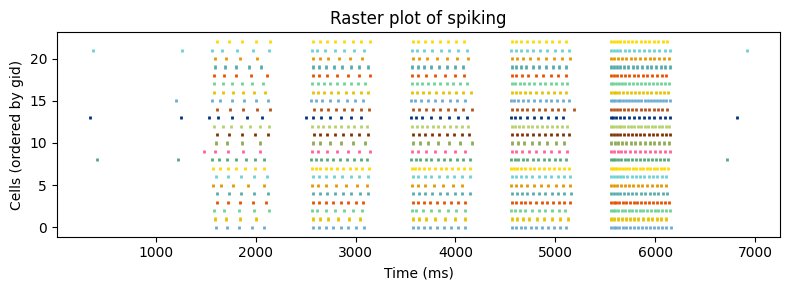

In [18]:
sim.analysis.plotRaster(timeRange=[0,7500], figSize=(8,3), popRates=False, labels = None);

Plotting recorded cell traces ... trace


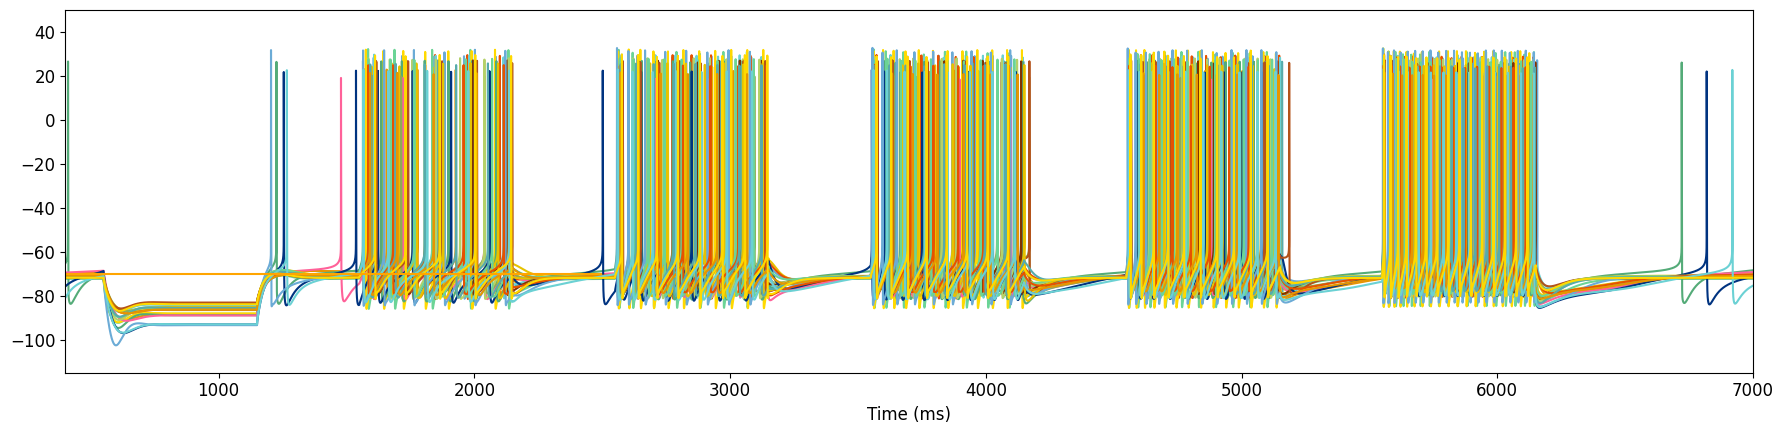

In [19]:
sim.analysis.plotTraces(include= [ii for ii in range(0,200)], timeRange=[400,7000], ylim=[-115, 50], axis=True, subtitles=False, legend=False, overlay=True, oneFigPer='trace', figSize=(18,4.5), showFig=False)
plt.hlines(xmin=0, xmax=2500, y=[-70], colors=['orange'])
plt.show()

# Load recordings

In [20]:
# pip install openpyxl

In [21]:
import pandas as pd

excel_file_path = "Spike_trains_steps_L4_elife_Aric.xlsx"

df_rs = pd.read_excel(excel_file_path, sheet_name="RS")
df_fs = pd.read_excel(excel_file_path, sheet_name="FS")
df_rip = pd.read_excel(excel_file_path, sheet_name="Ripplets")

print("DataFrame for sheet 'RS':")
print(df_rs.head())
print("\nDataFrame for sheet 'FS':")
print(df_fs.head())
print("\nDataFrame for sheet 'Ripplets':")
print(df_rip.head())

DataFrame for sheet 'RS':
     ms    -100      60      70     100     200
0  0.00 -71.045 -70.778 -69.588 -71.480 -70.015
1  0.05 -71.060 -70.686 -69.626 -71.648 -70.061
2  0.10 -71.037 -70.587 -69.618 -71.510 -70.007
3  0.15 -71.091 -70.686 -69.649 -71.503 -69.984
4  0.20 -71.053 -70.625 -69.687 -71.617 -70.061

DataFrame for sheet 'FS':
     ms    -320     240     280     400     600
0  0.00 -68.466 -68.558 -68.886 -69.473 -69.489
1  0.05 -68.390 -68.687 -68.848 -69.450 -69.427
2  0.10 -68.336 -68.703 -68.802 -69.550 -69.359
3  0.15 -68.466 -68.695 -68.871 -69.389 -69.328
4  0.20 -68.474 -68.550 -68.932 -69.679 -69.427

DataFrame for sheet 'Ripplets':
   031820_DFI_P41  FS 5 ms stim  Field  102920_DFI_P36  RS 2 ms stim  Field.1
0            0.00       -66.475 -0.004            0.00       -65.420   -0.046
1            0.05       -66.322 -0.011            0.05       -65.404    0.010
2            0.10       -66.269  0.011            0.10       -65.414    0.074
3            0.15       -6

In [22]:
import matplotlib.pyplot as plt

(0.0, 800.0)

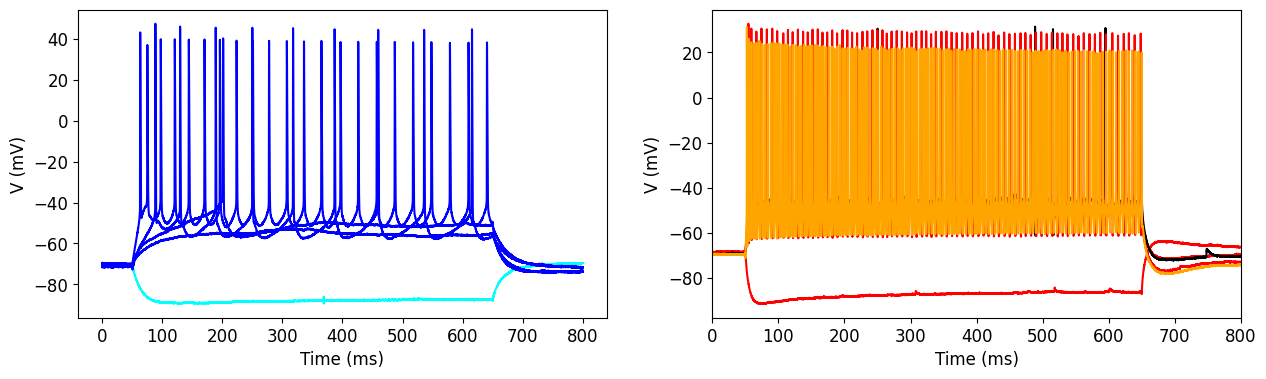

In [23]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
plt.plot(df_rs['ms'], df_rs[-100], color='cyan')
plt.plot(df_rs['ms'], df_rs[60], color='blue')
plt.plot(df_rs['ms'], df_rs[70], color='blue')
plt.plot(df_rs['ms'], df_rs[100], color='blue')
plt.plot(df_rs['ms'], df_rs[200], color='blue')
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
# plt.xlim(0, 50)
# plt.ylim(-72, -69)

plt.subplot(1, 2, 2)
plt.plot(df_fs['ms'], df_fs[-320], color='red')
plt.plot(df_fs['ms'], df_fs[240], color='red')
plt.plot(df_fs['ms'], df_fs[280], color='black')
plt.plot(df_fs['ms'], df_fs[400], color='red')
plt.plot(df_fs['ms'], df_fs[600], color='orange')
# plt.title('FS with 200 pA step current')
# plt.plot(df_rs['ms'], list(sim.simData['V_soma']['cell_4'])[10000:10000+len(df_rs['ms'])])
# plt.plot(df_rs['ms'], list(sim.simData['V_soma']['cell_5'])[10000:10000+len(df_rs['ms'])])
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(0, 800)
# plt.ylim(-80, -65)
# plt.xlim(0, 50)
# plt.ylim(-70, -68)

## Compare Resistence (100 < R_Mohm > 300) (Delta V)

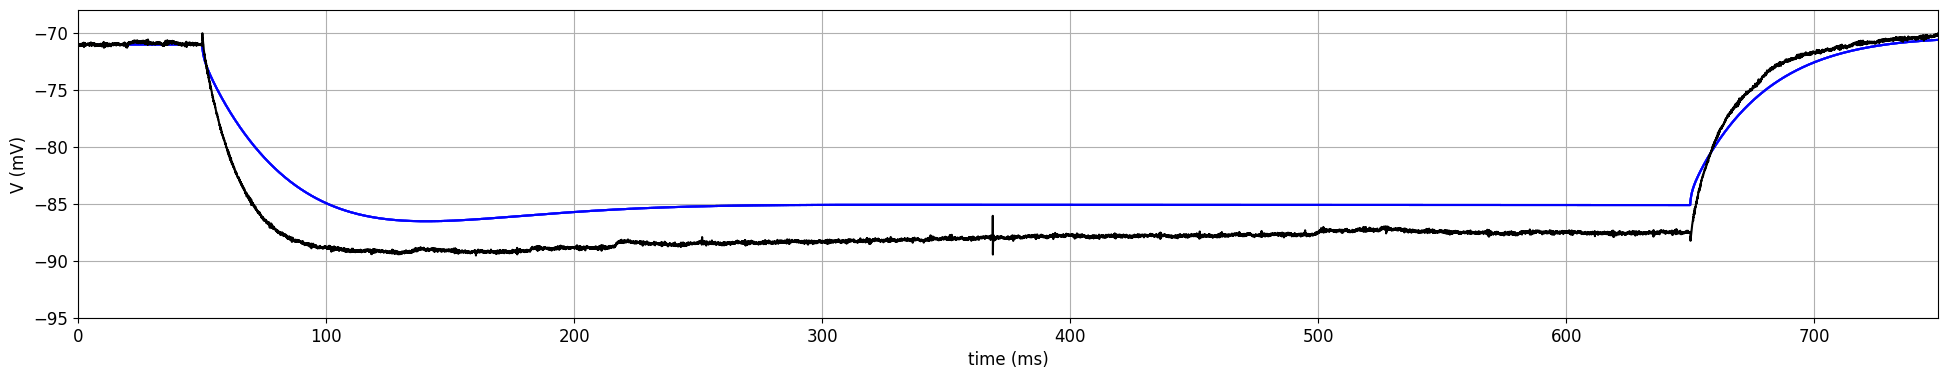

In [98]:
plt.figure(figsize=(24, 4))
# plt.figure(figsize=(24, 72))

# plt.subplot(10, 1, 1)
# plt.plot(df_rs['ms'], df_rs[-100].values, color='cyan')
# plt.plot(df_rs['ms'], df_rs[60])
# plt.plot(df_rs['ms'], df_rs[70])
# plt.plot(df_rs['ms'], df_rs[100])
# plt.plot(df_rs['ms'], df_rs[200])
# plt.title('RS with 200 pA step current')
plt.ylabel('V (mV)')
plt.xlim(0, 750)
ii = 0
cell_i_good = []
for i in range(1, 24):
    # if np.min(np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000:10000+len(df_rs['ms'])]-sim.simData['V_soma']['cell_'+str(i-1)][10000]) < -15 and np.min(np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000:10000+len(df_rs['ms'])]-sim.simData['V_soma']['cell_'+str(i-1)][10000]) > -20:
    
    # sim.simData['V_soma']['cell_'+str(i-1)][20000]-sim.simData['V_soma']['cell_'+str(i-1)][10000] < -12 and \
    # sim.simData['V_soma']['cell_'+str(i-1)][11800]-sim.simData['V_soma']['cell_'+str(i-1)][10000] < -12:
        cell_i_good.append(i)
        ii = ii + 1
        # plt.subplot(30, 1, ii)
        plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(1)])[10000:10000+len(df_rs['ms'])], color='blue', alpha=0.15)
        # plt.plot(df_rs['ms'], df_rs[-100].values, color='cyan')
        # plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000+120000:10000+120000+len(df_rs['ms'])]-sim.simData['V_soma']['cell_'+str(i-1)][10000+120000])
        plt.ylabel('V (mV)')
        plt.xlim(0, 750)
        plt.ylim(-95, -68)


plt.plot(df_rs['ms'], df_rs[-100].values, color='black')
plt.ylabel('V (mV)')
plt.xlabel('time (ms)')
plt.xlim(0, 750)
plt.grid(True)

# plt.show()

Plotting recorded cell traces ... trace


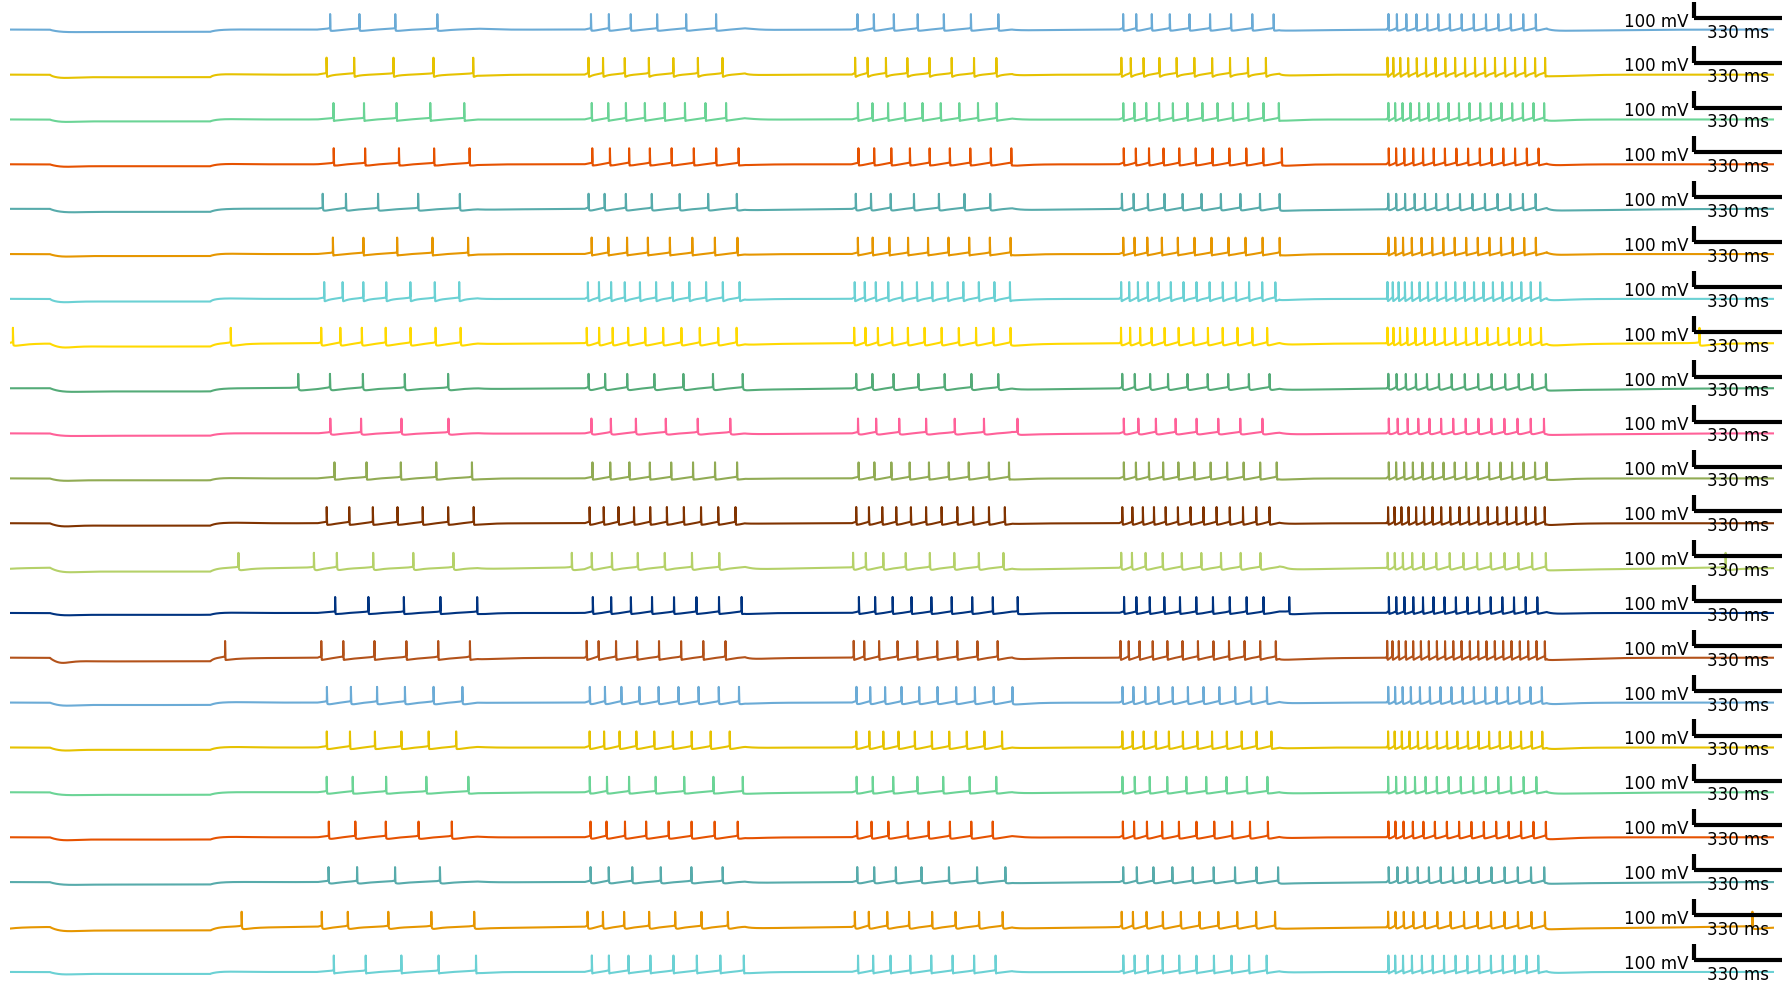

({'_trace_V_soma': <Figure size 1800x1050 with 22 Axes>},
 {'tracesData': [{'t': array([ 400.  ,  400.05,  400.1 , ..., 6999.9 , 6999.95, 7000.  ]),
    'cell_1_V_soma': array([-70.98312735, -70.98317883, -70.98323031, ..., -71.04437219,
           -71.04435718, -71.04434217])},
   {'t': array([ 400.  ,  400.05,  400.1 , ..., 6999.9 , 6999.95, 7000.  ]),
    'cell_2_V_soma': array([-72.27105089, -72.27109141, -72.27113187, ..., -72.27203534,
           -72.27203342, -72.27203151])},
   {'t': array([ 400.  ,  400.05,  400.1 , ..., 6999.9 , 6999.95, 7000.  ]),
    'cell_3_V_soma': array([-71.91511408, -71.91517906, -71.91524397, ..., -71.93482665,
           -71.93482518, -71.93482372])},
   {'t': array([ 400.  ,  400.05,  400.1 , ..., 6999.9 , 6999.95, 7000.  ]),
    'cell_4_V_soma': array([-71.68211209, -71.68219426, -71.68227636, ..., -71.71614542,
           -71.71614406, -71.71614271])},
   {'t': array([ 400.  ,  400.05,  400.1 , ..., 6999.9 , 6999.95, 7000.  ]),
    'cell_5_V_soma'

In [139]:
sim.analysis.plotTraces(include=cell_i_good, timeRange=[400,7000], ylim=[-115, 50], axis=False, subtitles=False, legend=True, overlay=False, oneFigPer='trace', figSize=(18,10.5), showFig=True)

## Compare 1st spike time at 100 pA

(300.0, 390.0)

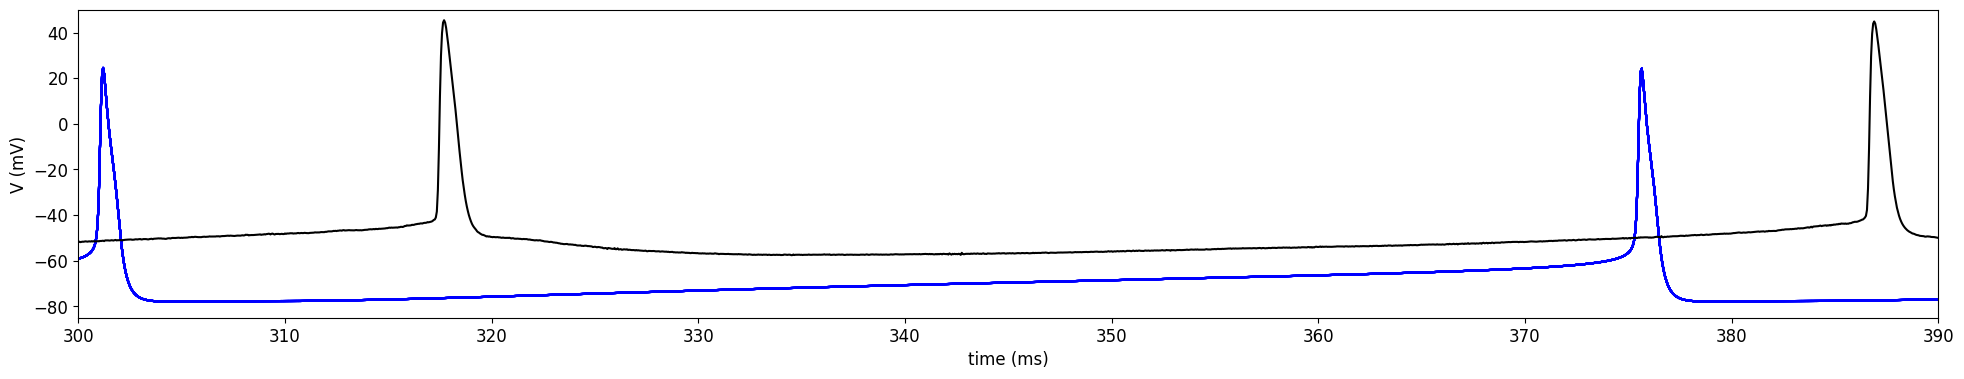

In [142]:
# plt.figure(figsize=(24, 72))
plt.figure(figsize=(24, 4))
plt.ylabel('V (mV)')
plt.xlim(0, 750)
for ii,i in enumerate(cell_i_good):
    # if np.max(np.array(sim.simData['V_soma']['cell_'+str(i-1)])[4*20000+10000:4*20000+10000+1600]) < -50:
        # plt.subplot(30, 1, ii+1)
        plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(18)])[4*20000+10000:4*20000+10000+len(df_rs['ms'])], color='blue',alpha = 1.0)
        # plt.plot(df_rs['ms'], df_rs[60].values, color='cyan')
        # plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000+120000:10000+120000+len(df_rs['ms'])]-sim.simData['V_soma']['cell_'+str(i-1)][10000+120000])
        plt.ylabel('V (mV)')
        plt.xlim(40, 750)
        # plt.xlim(0, 750)
        plt.ylim(-85, 50)

plt.plot(df_rs['ms'], df_rs[100].values, color='black')
plt.ylabel('V (mV)')
plt.xlabel('time (ms)')
plt.xlim(300, 390)
# plt.xlim(40, 150)

In [72]:
len(node_gid)

23

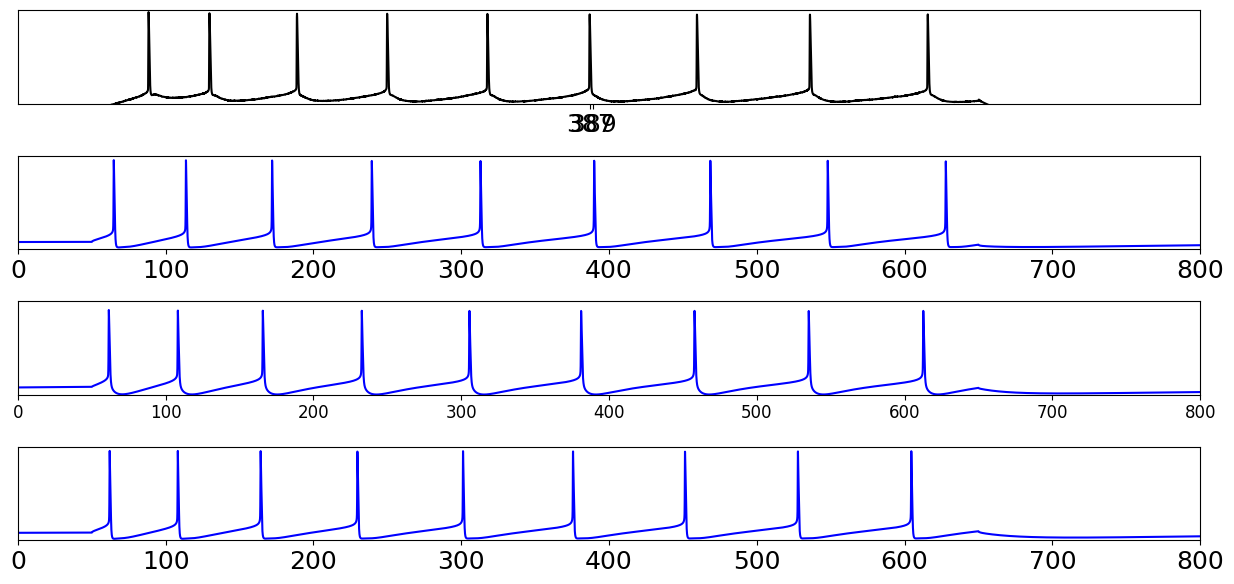

In [158]:
plt.figure(figsize=(12.5, 6.0))
i = len(node_gid)

plt.subplot(4, 1, 1)
plt.plot(df_rs['ms'], df_rs[100].values, color='black')
plt.ylim(-60, 50)
plt.xticks([387, 389], fontsize=18)
plt.xlim(00, 800.0)
plt.yticks([],fontsize=18)
plt.tight_layout()


plt.subplot(4, 1, 2)
plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(1)])[4*20000+10000:4*20000+10000+len(df_rs['ms'])], color='blue',alpha = 1.0)
plt.xlim(0, 800.0)
plt.ylim(-80, 30)
plt.yticks([],fontsize=18)
plt.xticks(fontsize=18)
plt.tight_layout()

plt.subplot(4, 1, 3)
plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(9)])[4*20000+10000:4*20000+10000+len(df_rs['ms'])], color='blue',alpha = 1.0)
plt.xlim(0, 800.0)
plt.ylim(-80, 30)
plt.yticks([],fontsize=18)
plt.xticks(None)
plt.tight_layout()

plt.subplot(4, 1, 4)
plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(18)])[4*20000+10000:4*20000+10000+len(df_rs['ms'])], color='blue',alpha = 1.0)
plt.xlim(0, 800.0)
plt.ylim(-80, 30)
plt.yticks([],fontsize=18)
plt.xticks(fontsize=18)
plt.tight_layout()

plt.savefig('Fig_traces_L4_RS_step_100pA_zoom.png', dpi=300)
# plt.show()

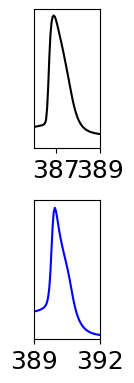

In [176]:
plt.figure(figsize=(1.5, 4.0))
i = len(node_gid)

plt.subplot(2, 1, 1)
plt.plot(df_rs['ms'], df_rs[100].values, color='black')
plt.ylim(-60, 50)
plt.xticks([387, 389], fontsize=18)
plt.xlim(386.0, 389.0)
plt.yticks([],fontsize=18)
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(1)])[4*20000+10000:4*20000+10000+len(df_rs['ms'])], color='blue',alpha = 1.0)
plt.xlim(389.2, 391.5)
plt.ylim(-80, 30)
plt.yticks([],fontsize=18)
plt.xticks([389,392],fontsize=18)
plt.tight_layout()

plt.savefig('Fig_traces_L4_RS_step_100pA_zoom.png', dpi=300)
# plt.show()

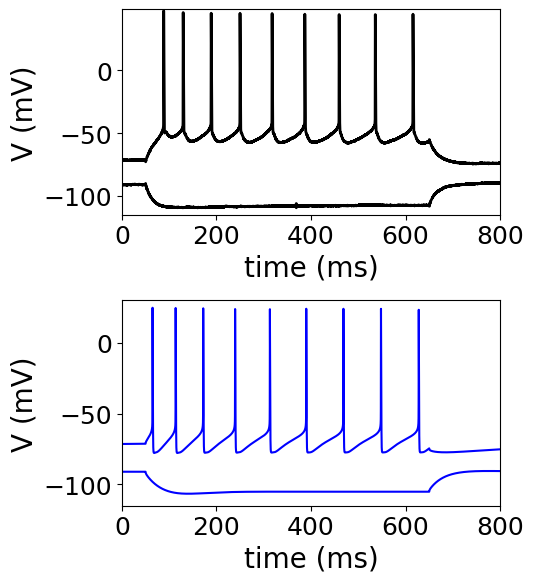

In [177]:
plt.figure(figsize=(5.5, 6.0))

plt.subplot(2, 1, 1)
plt.plot(df_rs['ms'], df_rs[100], linewidth = 2.0, color='black', label='Experimental')
plt.plot(df_rs['ms'], df_rs[-100] - 20, linewidth = 2.0, color='black')
plt.ylabel('V (mV)', fontsize=20)
plt.xlabel('time (ms)', fontsize=20)
plt.xlim(0, 800)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylim(-115, 49)
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(1)])[0*20000+10000:0*20000+10000+len(df_rs['ms'])] - 20, color='blue',alpha = 1.0)
plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(1)])[4*20000+10000:4*20000+10000+len(df_rs['ms'])], color='blue',alpha = 1.0, label='Model')
plt.ylabel('V (mV)', fontsize=20)
plt.xlabel('time (ms)', fontsize=20)
plt.xlim(0, 800)
plt.xticks(fontsize=18)
plt.yticks([-100,-50,0],fontsize=18)
plt.grid(False)
# plt.legend(fontsize=18)
plt.ylim(-115, 30)
plt.tight_layout()

plt.savefig('Fig_traces_L4_RS_step_100pA.png', dpi=300)
# plt.show()

## Compare number of spikes for 100 pA

(0.0, 750.0)

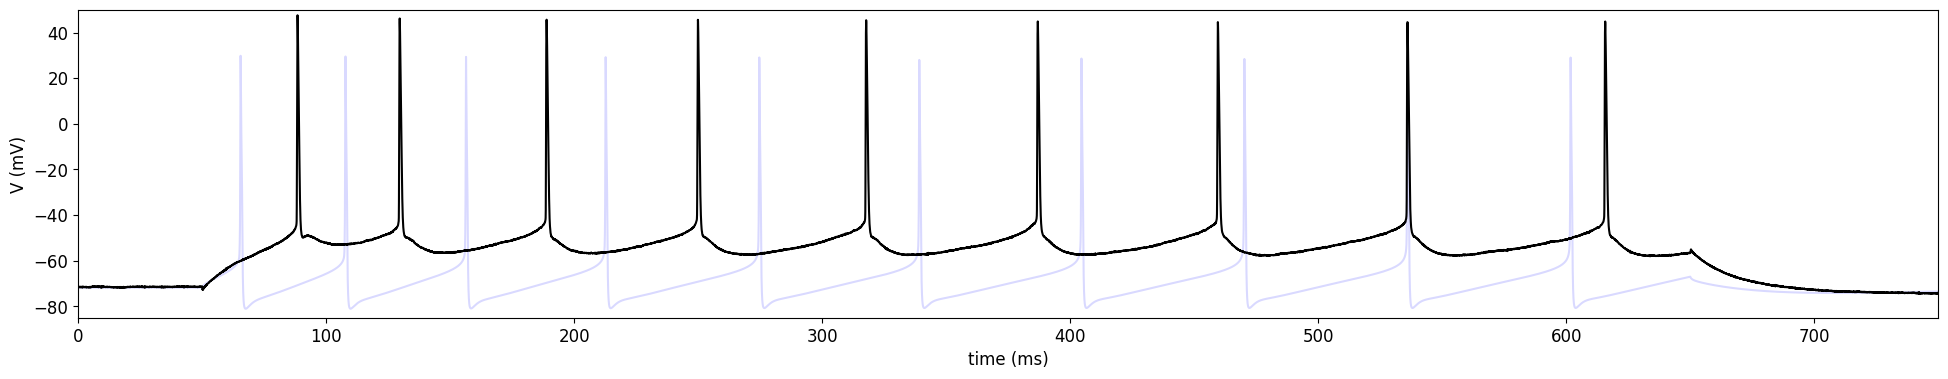

In [178]:
# plt.figure(figsize=(24, 72))
plt.figure(figsize=(24, 4))
plt.ylabel('V (mV)')
plt.xlim(0, 750)

    # if np.max(np.array(sim.simData['V_soma']['cell_'+str(i-1)])[4*20000+10000+1300:4*20000+10000+1500]) > 0:
        # plt.subplot(30, 1, ii+1)
plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[4*20000+10000:4*20000+10000+len(df_rs['ms'])], color='blue',alpha = 0.15)
# plt.plot(df_rs['ms'], df_rs[60].values, color='cyan')
# plt.plot(df_rs['ms'], np.array(sim.simData['V_soma']['cell_'+str(i-1)])[10000+120000:10000+120000+len(df_rs['ms'])]-sim.simData['V_soma']['cell_'+str(i-1)][10000+120000])
plt.ylabel('V (mV)')
# plt.xlim(40, 150)
plt.xlim(0, 750)
plt.ylim(-85, 50)

plt.plot(df_rs['ms'], df_rs[100].values, color='black')
plt.ylabel('V (mV)')
plt.xlabel('time (ms)')
plt.xlim(0, 750)
# plt.xlim(40, 150)

In [179]:
Firing = sim.analysis.calculateRate(timeRange=[4550,5150])
freq100 = []
cell_names = []
FR_RS_100pA = 9/0.600
print('%s \t= \t%.2f Hz' % ("Rs experimental at 100 pA", FR_RS_100pA))
for i, pop in enumerate(Firing[0]):
    if abs(FR_RS_100pA - Firing[1][i]) < 7.5 and i in cell_i_good:
        print('%s \t= \t%.2f Hz' % (pop, Firing[1][i]))
        freq100.append(Firing[1][i])
        cell_names.append(pop)
        
# Firing[1]

Calculating avg and peak firing rates ...
Rs experimental at 100 pA 	= 	15.00 Hz
L4_SSC_cADpyr_0 	= 	18.33 Hz
L4_SSC_cADpyr_1 	= 	15.00 Hz
L4_SSC_cADpyr_2 	= 	16.67 Hz
L4_SSC_cADpyr_3 	= 	20.00 Hz
L4_SSC_cADpyr_4 	= 	16.67 Hz
L4_SSC_cADpyr_5 	= 	15.00 Hz
L4_SSC_cADpyr_6 	= 	16.67 Hz
L4_SSC_cADpyr_8 	= 	20.00 Hz
L4_SSC_cADpyr_9 	= 	15.00 Hz
L4_SSC_cADpyr_10 	= 	13.33 Hz
L4_SSC_cADpyr_11 	= 	18.33 Hz
L4_SSC_cADpyr_12 	= 	21.67 Hz
L4_SSC_cADpyr_13 	= 	15.00 Hz
L4_SSC_cADpyr_14 	= 	16.67 Hz
L4_SSC_cADpyr_15 	= 	20.00 Hz
L4_SSC_cADpyr_16 	= 	18.33 Hz
L4_SSC_cADpyr_17 	= 	20.00 Hz
L4_SSC_cADpyr_18 	= 	15.00 Hz
L4_SSC_cADpyr_19 	= 	16.67 Hz
L4_SSC_cADpyr_20 	= 	15.00 Hz
L4_SSC_cADpyr_21 	= 	16.67 Hz
L4_SSC_cADpyr_22 	= 	16.67 Hz


In [180]:
cells_15hz = []
for i, pop in enumerate(Firing[0]):
    if Firing[1][i] == 10.0 and i in cell_i_good:
        cells_15hz.append(pop)

print("Cells with firing frequency = 15 Hz:", cells_15hz)

Cells with firing frequency = 15 Hz: []


Plotting recorded cell traces ... trace


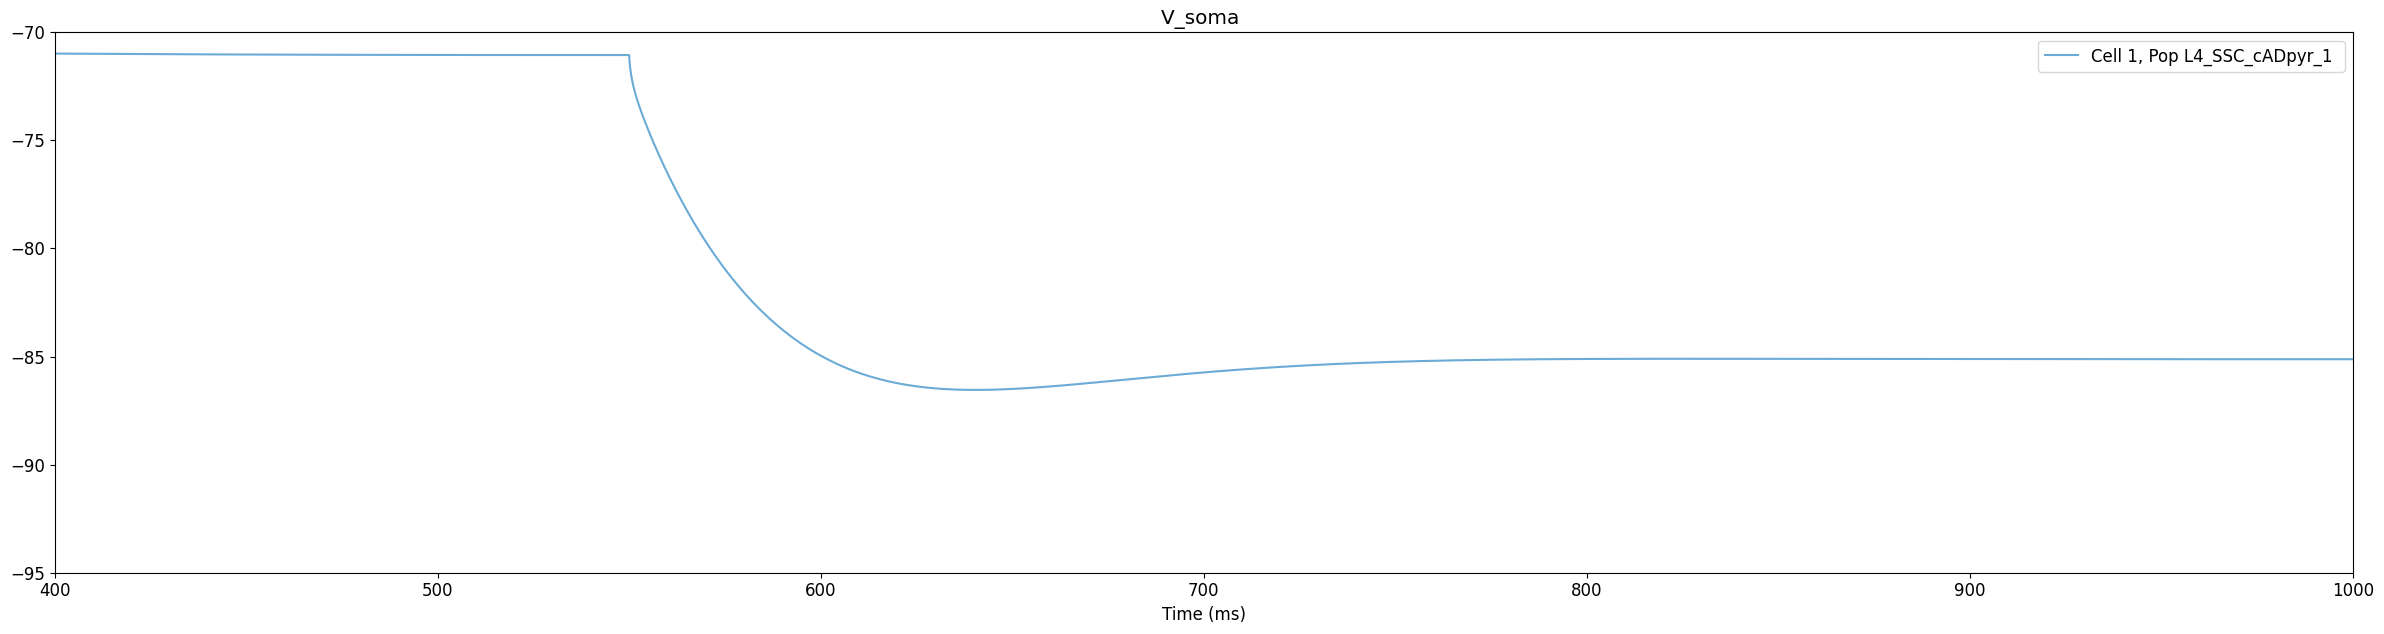

({'_trace_V_soma': <Figure size 2400x650 with 1 Axes>},
 {'tracesData': [{'t': array([ 400.  ,  400.05,  400.1 , ...,  999.9 ,  999.95, 1000.  ]),
    'cell_1_V_soma': array([-70.98312735, -70.98317883, -70.98323031, ..., -85.12365433,
           -85.12365457, -85.1236548 ])}],
  'include': [1]})

In [182]:
sim.analysis.plotTraces(include=[1], timeRange=[400,1000], ylim=[-95, -70], axis=True, overlay=True, oneFigPer='trace', figSize=(24,6.5))

In [39]:
import numpy as np


time = np.arange(0, sim.cfg.duration + sim.cfg.dt, sim.cfg.dt)


index_450ms = np.argmin(np.abs(time - 450))
index_1000ms = np.argmin(np.abs(time - 1000))

print(f"Tempo mais próximo para 450ms: {time[index_450ms]:.2f} ms")
print(f"Tempo mais próximo para 1000ms: {time[index_1000ms]:.2f} ms")
print("\nVoltagens da Soma para Células Selecionadas:")

cell_voltages = {}

for cell_full_name in cell_names:
    try:
        gid = cell_full_name.split('_')[-1]
        cell_name_key = f"cell_{gid}" 

        if cell_name_key in sim.simData['V_soma']:
            soma_voltage_trace = sim.simData['V_soma'][cell_name_key]
            
            if index_1000ms < len(soma_voltage_trace):
                voltage_450ms = soma_voltage_trace[index_450ms]
                voltage_1000ms = soma_voltage_trace[index_1000ms]
                
                cell_voltages[cell_full_name] = { #
                    'V_450ms': voltage_450ms,
                    'V_1000ms': voltage_1000ms
                }
                print(f"{cell_full_name}: V_soma aos 450 ms = {voltage_450ms:.2f} mV, V_soma aos 1000 ms = {voltage_1000ms:.2f} mV")
            else:
                print(f"Aviso: O trace de voltagem para {cell_full_name} ({cell_name_key}) é muito curto para acessar 1000 ms.")
        else:
            print(f"Aviso: Dados de V_soma não encontrados para a chave: {cell_name_key} (original: {cell_full_name})")
    except Exception as e:
        print(f"Erro ao processar a célula {cell_full_name}: {e}")


Tempo mais próximo para 450ms: 450.00 ms
Tempo mais próximo para 1000ms: 1000.00 ms

Voltagens da Soma para Células Selecionadas:
L4_SSC_cADpyr_0: V_soma aos 450 ms = -71.64 mV, V_soma aos 1000 ms = -83.76 mV
L4_SSC_cADpyr_1: V_soma aos 450 ms = -71.03 mV, V_soma aos 1000 ms = -85.12 mV
L4_SSC_cADpyr_2: V_soma aos 450 ms = -72.29 mV, V_soma aos 1000 ms = -88.19 mV
L4_SSC_cADpyr_3: V_soma aos 450 ms = -71.95 mV, V_soma aos 1000 ms = -83.93 mV


In [40]:
I = 100 #pA
membrane_resistances = []

for cell_full_name, voltages in cell_voltages.items():
    delta_V = voltages['V_450ms'] - voltages['V_1000ms']
    
    Rm = (delta_V / I) * 1000
    membrane_resistances.append(Rm)


    print(f"{cell_full_name}: ΔV = {delta_V:.2f} mV, Rm = {Rm:.2f}")


L4_SSC_cADpyr_0: ΔV = 12.12 mV, Rm = 121.22
L4_SSC_cADpyr_1: ΔV = 14.10 mV, Rm = 140.97
L4_SSC_cADpyr_2: ΔV = 15.90 mV, Rm = 159.00
L4_SSC_cADpyr_3: ΔV = 11.98 mV, Rm = 119.75


In [41]:
print(list(sim.simData['V_soma'].keys())[:10]) 

['cell_0', 'cell_1', 'cell_2', 'cell_3', 'cell_4', 'cell_5', 'cell_6', 'cell_7', 'cell_8', 'cell_9']


In [42]:
from scipy.signal import find_peaks

def measure_spike_width_half_height(trace, time, threshold=-40):
    """
    Measures the spike width at half-height (SWHH) for a single voltage trace.
    Returns a list of SWHH values (ms) for all spikes detected above threshold.
    """
    trace = np.array(trace)
    time = np.array(time)
    swhh_list = []

    # Find all peaks above threshold

    peaks, _ = find_peaks(trace, height=threshold)
    for peak_idx in peaks:
        peak_v = trace[peak_idx]
        # Estimate baseline as the minimum before the spike (within 10 ms window)
        baseline_idx = max(0, peak_idx - int(10 / (time[1] - time[0])))
        baseline_v = np.min(trace[baseline_idx:peak_idx])
        half_height = baseline_v + 0.5 * (peak_v - baseline_v)

        # Find left crossing
        left = peak_idx
        while left > 0 and trace[left] > half_height:
            left -= 1
        # Linear interpolation for more accurate crossing
        if left < peak_idx and trace[left+1] != trace[left]:
            t_left = time[left] + (half_height - trace[left]) * (time[left+1] - time[left]) / (trace[left+1] - trace[left])
        else:
            t_left = time[left]

        # Find right crossing
        right = peak_idx
        while right < len(trace)-1 and trace[right] > half_height:
            right += 1
        if right > peak_idx and trace[right-1] != trace[right]:
            t_right = time[right-1] + (half_height - trace[right-1]) * (time[right] - time[right-1]) / (trace[right] - trace[right-1])
        else:
            t_right = time[right]

        swhh = t_right - t_left
        swhh_list.append(swhh)

    return swhh_list

# Calculate SWHH for each cell in freq100
swhh_results = {}
for cell_full_name in cell_names:
    gid = cell_full_name.split('_')[-1]
    cell_key = f"cell_{gid}"
    if cell_key in sim.simData['V_soma']:
        trace = np.array(sim.simData['V_soma'][cell_key])
        swhh_list = measure_spike_width_half_height(trace, time)
        swhh_results[cell_full_name] = swhh_list

# Print mean SWHH for each cell
for cell, swhh_list in swhh_results.items():
    if swhh_list:
        print(f"{cell}: mean SWHH = {np.mean(swhh_list):.2f} ms, n_spikes = {len(swhh_list)}")
    else:
        print(f"{cell}: no spikes detected above threshold")

L4_SSC_cADpyr_0: mean SWHH = 0.63 ms, n_spikes = 50
L4_SSC_cADpyr_1: mean SWHH = 0.71 ms, n_spikes = 40
L4_SSC_cADpyr_2: mean SWHH = 0.60 ms, n_spikes = 48
L4_SSC_cADpyr_3: mean SWHH = 0.63 ms, n_spikes = 51


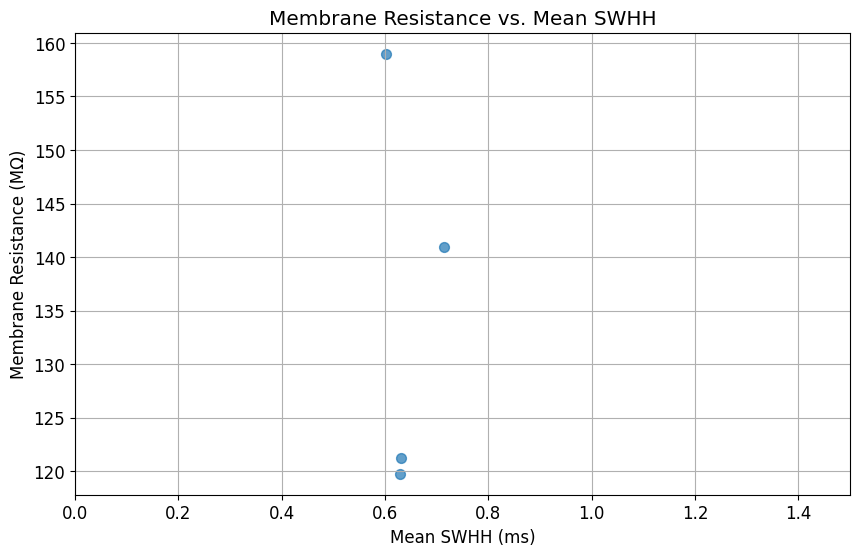

In [43]:
# Calculate mean SWHH for each cell in freq100
mean_swhh = []
for cell in cell_names:
    swhh = swhh_results.get(cell, [])
    if swhh:
        mean_swhh.append(np.mean(swhh))
    else:
        mean_swhh.append(np.nan)

plt.figure(figsize=(10, 6))
plt.scatter(mean_swhh, membrane_resistances, s=50, alpha=0.7)
plt.xlabel('Mean SWHH (ms)')
plt.xlim(0, 1.5)
plt.ylabel('Membrane Resistance (MΩ)')
plt.title('Membrane Resistance vs. Mean SWHH')
plt.grid(True)
plt.show()

In [44]:
print(f"Number of cells with 15 Hz firing frequency: {len(cells_15hz)}")
print("Cells:", cells_15hz)


Number of cells with 15 Hz firing frequency: 0
Cells: []


In [45]:
# Find the gid for the cell 'L4_UPC_cADpyr_21'
for gid, name in cellName_list.items():
    if name.startswith('L4_TPC_cADpyr_56'):
        print(f"GID for L4_TPC_cADpyr_56: {gid}")
        break

In [46]:
gid = 112501

hoc_file = nodesinfo['model_template'][gid][4:] + '.hoc'
morphology_file = nodesinfo['morphology'][gid] + '.asc'

print("Hoc file:", hoc_file)
print("Morphology file:", morphology_file)

Hoc file: cADpyr_L4UPC.hoc
Morphology file: dend-rp120608_P_3_idB_axon-rp120521_P_1_idC_-_Scale_x1.000_y0.950_z1.000.asc


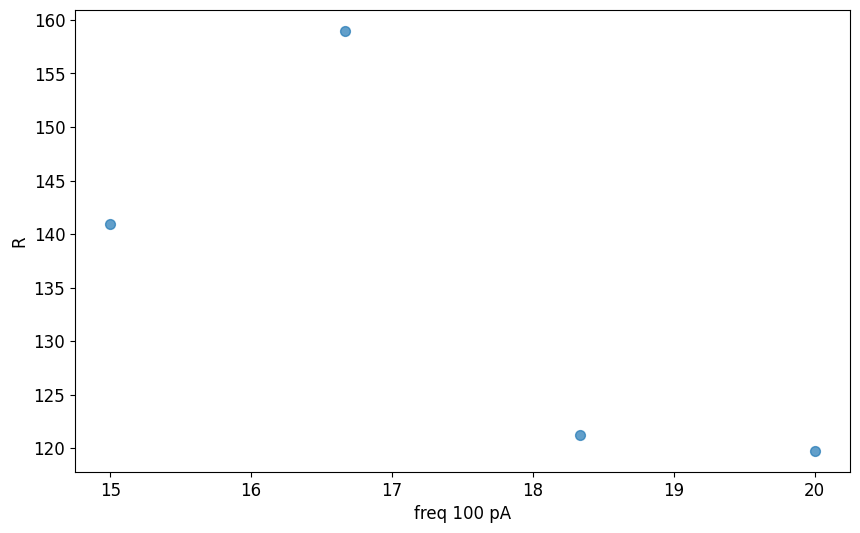

In [47]:
plt.figure(figsize=(10, 6)) 
plt.scatter(freq100, membrane_resistances, s=50, alpha=0.7)
plt.ylabel('R')
plt.xlabel('freq 100 pA')

plt.grid(False)

plt.show()

(0.0, 750.0)

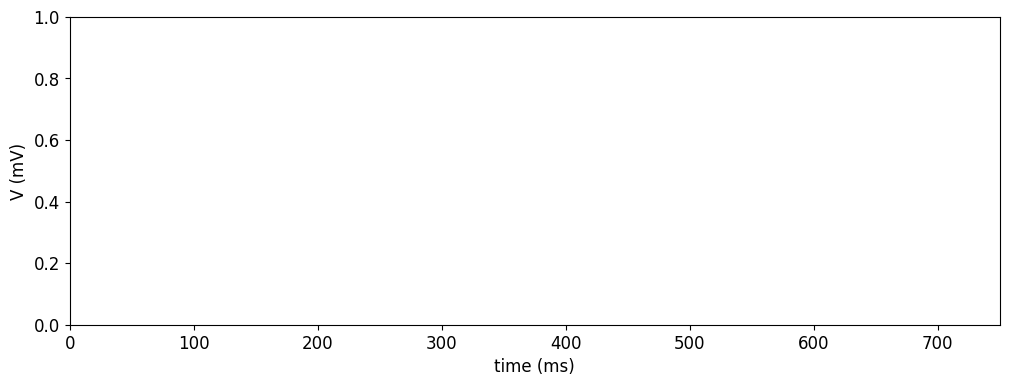

In [48]:
plt.figure(figsize=(12, 4))
plt.ylabel('V (mV)')
plt.xlim(0, 750)
for ii, cell_full_name in enumerate(cells_15hz):
    cell_gid = cell_full_name.split('_')[-1]
    cell_key = f'cell_{cell_gid}'
    if cell_key in sim.simData['V_soma']:
        trace = sim.simData['V_soma'][cell_key]
        plt.subplot(len(cells_15hz), 1, ii+1)
        plt.plot(df_rs['ms'], np.array(trace)[4*20000+10000:4*20000+10000+len(df_rs['ms'])], color='blue')
        plt.plot(df_rs['ms'], df_rs[100].values, color='black')
        plt.ylabel('V (mV)')
        plt.xlim(0, 750)
        plt.ylim(-85, 50)

plt.ylabel('V (mV)')
plt.xlabel('time (ms)')
plt.xlim(0, 750)
# plt.xlim(40, 150)

In [49]:
for name in cell_names:
    print(name)

L4_SSC_cADpyr_0
L4_SSC_cADpyr_1
L4_SSC_cADpyr_2
L4_SSC_cADpyr_3


### Ultra Fast Ripples

(0.0, 25.0)

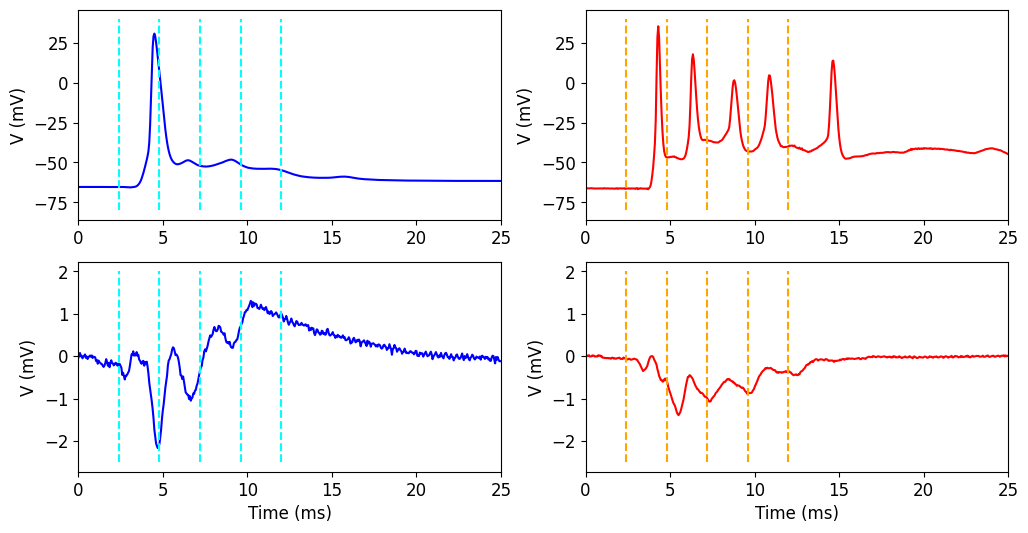

In [50]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(df_rip['102920_DFI_P36'], df_rip['RS 2 ms stim'], color='blue')
plt.vlines(x=[2.4,4.8,7.2,9.6,12.0],ymin=-80, ymax=40, colors='cyan', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlim(0, 25)
plt.subplot(2, 2, 3)
plt.plot(df_rip['102920_DFI_P36'], df_rip['Field.1'], color='blue')
plt.vlines(x=[2.4,4.8,7.2,9.6,12.0],ymin=-2.5, ymax=2, colors='cyan', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(0, 25)

plt.subplot(2, 2, 2)
plt.plot(df_rip['031820_DFI_P41'], df_rip['FS 5 ms stim'], color='red')
plt.vlines(x=[2.4,4.8,7.2,9.6,12.0],ymin=-80, ymax=40, colors='orange', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlim(0, 25)
plt.subplot(2, 2, 4)
plt.plot(df_rip['031820_DFI_P41'], df_rip['Field'], color='red')
plt.vlines(x=[2.4,4.8,7.2,9.6,12.0],ymin=-2.5, ymax=2, colors='orange', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(0, 25)